In [200]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [201]:
data=pd.read_csv("/home/hammadali08/Personal/CSV file/Churn_Modelling.csv")
data

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,9996,15606229,Obijiaku,771,France,Male,39,5,0.00,2,1,0,96270.64,0
9996,9997,15569892,Johnstone,516,France,Male,35,10,57369.61,1,1,1,101699.77,0
9997,9998,15584532,Liu,709,France,Female,36,7,0.00,1,0,1,42085.58,1
9998,9999,15682355,Sabbatini,772,Germany,Male,42,3,75075.31,2,1,0,92888.52,1


In [202]:
data['Exited'].value_counts()

Exited
0    7963
1    2037
Name: count, dtype: int64

In [203]:
Geography=pd.get_dummies(data['Geography'],drop_first=True)
Geography=Geography.astype('int')

In [204]:
Gender=pd.get_dummies(data['Gender'],drop_first=True)
Gender=Gender.astype('int')

In [205]:
data.drop(['Geography','Gender','Surname'],axis=1,inplace=True)

In [206]:
x=data.iloc[:,:-1]
y=data['Exited']

In [207]:
pd.concat([x,Geography,Gender],axis=1)

,RowNumber,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Germany,Spain,Male
0,1,15634602,619,42,2,0.00,1,1,1,101348.88,0,0,0
1,2,15647311,608,41,1,83807.86,1,0,1,112542.58,0,1,0
2,3,15619304,502,42,8,159660.80,3,1,0,113931.57,0,0,0
3,4,15701354,699,39,1,0.00,2,0,0,93826.63,0,0,0
4,5,15737888,850,43,2,125510.82,1,1,1,79084.10,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,9996,15606229,771,39,5,0.00,2,1,0,96270.64,0,0,1
9996,9997,15569892,516,35,10,57369.61,1,1,1,101699.77,0,0,1
9997,9998,15584532,709,36,7,0.00,1,0,1,42085.58,0,0,0
9998,9999,15682355,772,42,3,75075.31,2,1,0,92888.52,1,0,1


In [208]:
from sklearn.preprocessing import StandardScaler
sts=StandardScaler()
sts.fit(x)

StandardScaler()

In [209]:
x=pd.DataFrame(sts.transform(x),columns=x.columns)
x

,RowNumber,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary
0,-1.731878,-0.783213,-0.326221,0.293517,-1.041760,-1.225848,-0.911583,0.646092,0.970243,0.021886
1,-1.731531,-0.606534,-0.440036,0.198164,-1.387538,0.117350,-0.911583,-1.547768,0.970243,0.216534
2,-1.731185,-0.995885,-1.536794,0.293517,1.032908,1.333053,2.527057,0.646092,-1.030670,0.240687
3,-1.730838,0.144767,0.501521,0.007457,-1.387538,-1.225848,0.807737,-1.547768,-1.030670,-0.108918
4,-1.730492,0.652659,2.063884,0.388871,-1.041760,0.785728,-0.911583,0.646092,0.970243,-0.365276
...,...,...,...,...,...,...,...,...,...,...
9995,1.730492,-1.177652,1.246488,0.007457,-0.004426,-1.225848,0.807737,0.646092,-1.030670,-0.066419
9996,1.730838,-1.682806,-1.391939,-0.373958,1.724464,-0.306379,-0.911583,0.646092,0.970243,0.027988
9997,1.731185,-1.479282,0.604988,-0.278604,0.687130,-1.225848,-0.911583,-1.547768,0.970243,-1.008643
9998,1.731531,-0.119356,1.256835,0.293517,-0.695982,-0.022608,0.807737,0.646092,-1.030670,-0.125231


In [210]:
from sklearn.model_selection import train_test_split

In [211]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=0)

In [212]:
import tensorflow as tf

In [213]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Dropout
from keras.callbacks import EarlyStopping

In [214]:
ann=Sequential()

In [215]:
ann.add(Dense(10,activation='relu'))
ann.add(Dense(8,activation='relu'))
ann.add(Dropout(0.2))
ann.add(Dense(6,activation='relu'))
ann.add(Dense(1,activation='sigmoid'))

In [216]:
adm=tf.optimizers.Adam(learning_rate=0.01)
ann.compile(optimizer=adm,loss='binary_crossentropy',metrics=['accuracy'])

In [217]:
early_stopping=tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    min_delta=0.001,
    patience=10,
    verbose=1,
    mode="auto",
    baseline=None,
    restore_best_weights=False,
    start_from_epoch=0,
)

In [218]:
ann.fit(x_train,y_train,validation_split=0.33,batch_size=50,epochs=100,callbacks=early_stopping)

Epoch 1/100
108/108 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.7647 - loss: 0.5247 - val_accuracy: 0.7989 - val_loss: 0.4484
Epoch 2/100
108/108 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8186 - loss: 0.4355 - val_accuracy: 0.8342 - val_loss: 0.4138
Epoch 3/100
108/108 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8393 - loss: 0.3976 - val_accuracy: 0.8470 - val_loss: 0.3874
Epoch 4/100
108/108 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8410 - loss: 0.3852 - val_accuracy: 0.8455 - val_loss: 0.3820
Epoch 5/100
108/108 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8449 - loss: 0.3811 - val_accuracy: 0.8482 - val_loss: 0.3795
Epoch 6/100
108/108 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8462 - loss: 0.3764 - val_accuracy: 0.8519 - val_loss: 0.3769
Epoch 7/100
108/108 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8436 - loss: 0.3756 - val_accuracy: 0.8512 - val_loss: 0.3752
Epoch 8/100
108/108 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8453 - loss: 0.3698 - val_accu

In [219]:
ann.history.history.keys()

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])

In [220]:
train_loss=ann.history.history['loss']
test_loss=ann.history.history['val_loss']

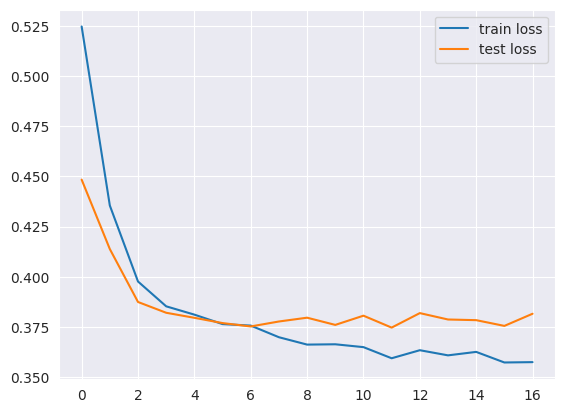

In [221]:
plt.plot(train_loss,label='train loss')
plt.plot(test_loss,label='test loss')
plt.legend()
plt.show()

In [222]:
train_accuracy=ann.history.history['accuracy']
test_accuracy=ann.history.history['val_accuracy']

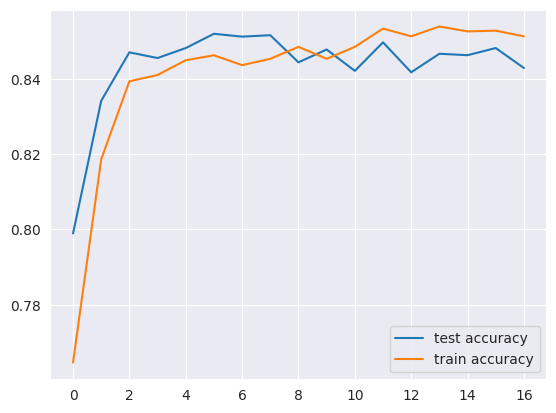

In [223]:
plt.plot(test_accuracy, label='test accuracy')
plt.plot(train_accuracy, label='train accuracy')
plt.legend()
plt.show()

In [224]:
prd_y = ann.predict(x_train)
prd_y_data = []
for i in prd_y:
    if i >= 0.5:
        prd_y_data.append(1)
    else:
        prd_y_data.append(0)

250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 834us/step


In [225]:
prd = ann.predict(x_test)
prd_data = []
for i in prd:
    if i >= 0.5:
        prd_data.append(1)
    else:
        prd_data.append(0)

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


<Axes: >

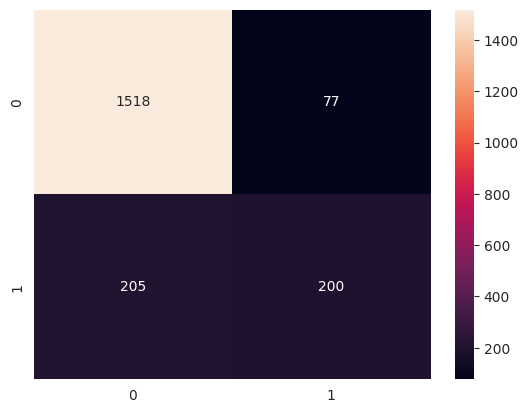

In [226]:
from sklearn.metrics import confusion_matrix
sns.heatmap(confusion_matrix(y_test, prd_data),annot=True,fmt="d")

In [227]:
from sklearn.metrics import classification_report
classification_report(y_test, prd_data)

'              precision    recall  f1-score   support\n\n           0       0.88      0.95      0.92      1595\n           1       0.72      0.49      0.59       405\n\n    accuracy                           0.86      2000\n   macro avg       0.80      0.72      0.75      2000\nweighted avg       0.85      0.86      0.85      2000\n'

In [228]:
from sklearn.metrics import accuracy_score
accuracy_score(y_test, prd_data)

0.859

In [229]:
accuracy_score(y_train, prd_y_data)

0.852375

In [230]:
ann.weights

[<Variable path=sequential_4/dense_40/kernel, shape=(10, 10), dtype=float32, value=[[-9.28208530e-02  9.91027802e-02 -4.41175094e-03  2.40059480e-01
   -4.62784246e-03  4.98204008e-02  2.36940354e-01  2.63560146e-01
    3.02255541e-01 -4.09196466e-01]
  [ 1.58862993e-02 -1.09073311e-01 -4.35879320e-01 -1.04097694e-01
   -5.72327897e-03  1.00058364e-02 -2.40626320e-01  3.54087383e-01
   -1.81598485e-01 -1.12863354e-01]
  [ 4.46592905e-02 -5.84098250e-02 -1.80681139e-01  2.94901605e-04
   -3.41286696e-02 -9.68257487e-02 -2.58242756e-01  1.33331478e-01
   -1.21575847e-01  5.56622267e-01]
  [ 4.45564508e-01  5.18377662e-01 -9.03271437e-01 -1.57958555e+00
   -9.08992648e-01 -1.26975864e-01  1.34099454e-01  5.64952731e-01
    2.44948655e-01 -9.20521080e-01]
  [ 1.56366974e-02 -6.32667959e-01  2.08011180e-01 -1.64548635e-01
   -7.04304352e-02 -5.82032390e-02 -2.37576216e-01  1.49333864e-01
    4.49997839e-03 -9.15191174e-02]
  [-1.58683434e-01 -7.45295212e-02 -6.66632712e-01 -3.04743052e-01
 